<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/Unit7/Paarth_Bamb_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

In [ ]:
!pip install git+https://github.com/pydata/xarray.git
!pip install bambi

!pip install preliz

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr
import bambi as bmb
import pymc as pm

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Polynomials are useful when you think the relationship between variables follows some curved nonlinear pattern. If you're modeling height vs. age, it's not a straight line, and it curves. Polynomials let you capture that shape without needing a different model structure. They're also pretty interpretable and easy to implement.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

The big downside is overfitting. Higher degree polynomials can twist and bend to fit your training data really well but then fall apart on new data. They're also really sensitive to outliers and can behave wildly outside the range of your data (extrapolation is basically useless). So if your data is noisy or you care about predictions outside your observed range, polynomials can be a bad choice.

**Task3**:

What's the point of using b splines?

B splines are a smarter version of polynomials. Instead of fitting one polynomial across all your data, splines fit piecewise polynomials that connect smoothly at certain points called knots. The benefit is you get flexibility where you need it without the crazy behavior polynomials can have at the edges.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

From what I understand, a Gaussian Process is like putting a probability distribution over entire functions instead of over entire functions. Instead of saying "the answer is 5" it says "here's a whole range of plausible functions that could describe this data, and here's how confident we are in each." It uses the idea that nearby points should be more similar to each other, which makes intuitive sense. Honestly it still feels a bit abstract to me but that's the best I can do.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
model_poly_1 = bmb.Model("height ~ weight", howell)
idata_poly_1 = model_poly_1.fit()

model_poly_4 = bmb.Model("height ~ poly(weight, degree=4)", howell)
idata_poly_4 = model_poly_4.fit()

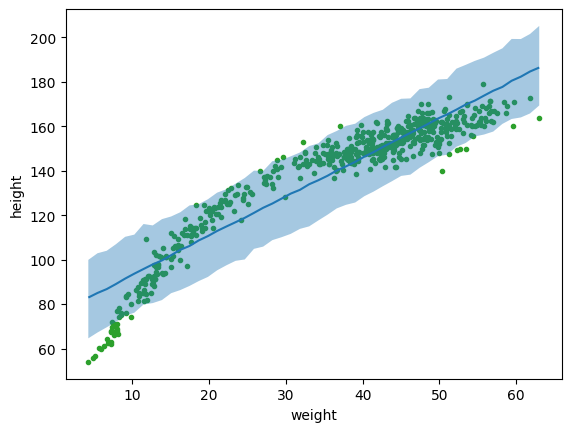

In [ ]:
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

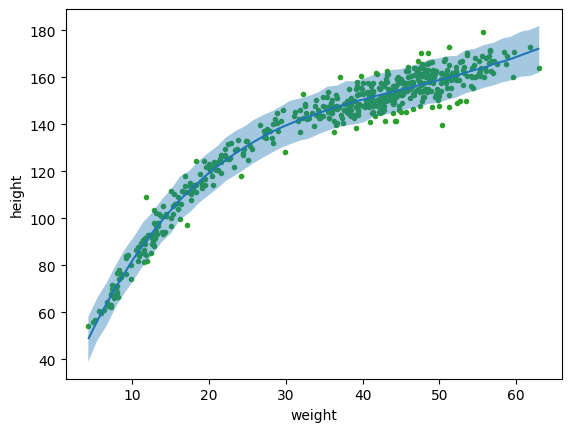

In [ ]:
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='height'>

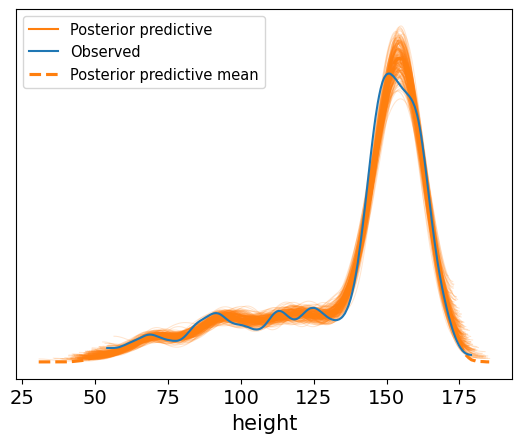

In [ ]:
model_poly_4.predict(idata_poly_4, kind="pps")
az.plot_ppc(idata_poly_4, num_pp_samples=200, colors=["C1", "C0", "C1"])

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

One thing I learned is that you can actually combine two totally different datasets, for example the modern Mauna Loa atmospheric measurements and ancient Antarctic ice core data going back to 13 AD, into a single GP model. The ice core CO₂ comes from air bubbles trapped in ice that hardened over time, so it's less precise than the direct atmospheric readings, but it extends the record back almost 2,000 years.What's cool is the GP handles the fact that these two data sources have different levels of uncertainty by giving them separate noise parameters. I didn't realize GPs could be set up to accommodate that kind of messy data situation.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

My favorite graph is the GP decomposition plot that breaks the CO₂ signal into separate components all plotted on the same axis. The total fit is shown in red with a shaded uncertainty band, the long-term trend in blue, medium variation in green, and the seasonal process in orange. I love it because it makes something that sounds impossibly complicated (a GP over 2,000 years of data) readable. You can point to the orange line and say "that's just the yearly plant growth cycle" and point to the blue line and say "that's industrialization."